# Preliminaries

In [1]:
import json
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import itertools
import numpy as np
from scipy import stats
    
%load_ext autoreload
%autoreload 2

In [2]:
from literal_listener import StatelessLiteralListener

from configuration import TRUE_REWARDS

In [3]:
TEST_CONTEXT = [{'color': 'red', 'shape': 'spotted'},
                {'color': 'red', 'shape': 'striped'},
                {'color': 'blue', 'shape': 'spotted'}]

In [4]:
import torch

cuda_available = torch.cuda.is_available()
print(print(f"Is GPU available? {cuda_available}"))

# 2. Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.rand(3, 3).to(device) 

Is GPU available? True
None
Using device: cuda


# Literal Listener

## Acting from Instructions

In [5]:
listener = StatelessLiteralListener(alphaL=3)

In [6]:
instruction_present = {"type": "instruction", "color": "red", "shape": "spotted"}
print("\nUtterance: {}".format(instruction_present))
for a in TEST_CONTEXT:
    print("\t{} : {}".format(a, listener._prob_action_from_instruction(a, TEST_CONTEXT, instruction_present)))

instruction_absent = {"type": "instruction", "color": "green", "shape": "spotted"}
print("\nUtterance: {}".format(instruction_absent))
for a in TEST_CONTEXT:
    print("\t{} : {}".format(a, listener._prob_action_from_instruction(a, TEST_CONTEXT, instruction_absent)))


Utterance: {'type': 'instruction', 'color': 'red', 'shape': 'spotted'}
	{'color': 'red', 'shape': 'spotted'} : 1
	{'color': 'red', 'shape': 'striped'} : 0
	{'color': 'blue', 'shape': 'spotted'} : 0

Utterance: {'type': 'instruction', 'color': 'green', 'shape': 'spotted'}
	{'color': 'red', 'shape': 'spotted'} : 0.3333333333333333
	{'color': 'red', 'shape': 'striped'} : 0.3333333333333333
	{'color': 'blue', 'shape': 'spotted'} : 0.3333333333333333


## Acting from Descriptions
Given a message $u$ which consists of a feature-value tuple $(\phi, \mathbb{R})$, condition worlds $w$ and return only those with are literally consistent with that utterance. Choose actions w.r.t. the posterior beliefs.

In [7]:
description = {"type": "description", "feature": "red", "value":1}
print("Utterance: {}".format(description))
for a in TEST_CONTEXT:
    print("\t{} : {}".format(a, listener._prob_action_from_description(a, TEST_CONTEXT, description)))


description_spotted = {"type": "description", "feature": "spotted", "value":1}
print("\nUtterance: {}".format(description_spotted))
for a in TEST_CONTEXT:
    print("\t{} : {}".format(a, listener._prob_action_from_description(a, TEST_CONTEXT, description_spotted)))

Utterance: {'type': 'description', 'feature': 'red', 'value': 1}
	{'color': 'red', 'shape': 'spotted'} : 0.4878555511603684
	{'color': 'red', 'shape': 'striped'} : 0.4878555511603684
	{'color': 'blue', 'shape': 'spotted'} : 0.024288897679263205

Utterance: {'type': 'description', 'feature': 'spotted', 'value': 1}
	{'color': 'red', 'shape': 'spotted'} : 0.4878555511603684
	{'color': 'red', 'shape': 'striped'} : 0.024288897679263205
	{'color': 'blue', 'shape': 'spotted'} : 0.4878555511603684


### Present Rewards

In [8]:
print("Instructions - Present Rewards")
print("\tGood Instruction: {}".format(listener.present_rewards(instruction_present, TEST_CONTEXT, TRUE_REWARDS)))
print("\tNot Present Instruction: {}".format(listener.present_rewards(instruction_absent, TEST_CONTEXT, TRUE_REWARDS)))

print("\nDescriptions - Present Rewards")
print("\tPresent Rewards: {}".format(listener.present_rewards(description, TEST_CONTEXT, TRUE_REWARDS)))
print("\tPresent Rewards: {}".format(listener.present_rewards(description_spotted, TEST_CONTEXT, TRUE_REWARDS)))

Instructions - Present Rewards
	Good Instruction: -1
	Not Present Instruction: -1.3333333333333333

Descriptions - Present Rewards
	Present Rewards: -0.5607222441981581
	Present Rewards: -1.9514222046414735


### Future Feature Counts / Rewards

In [9]:
listener = StatelessLiteralListener(alphaL=3)
avg_features_advice = listener.future_feature_counts({"type": "description", "feature": "green", "value": 2})

expected_rewards_advice = listener.feature_count_rewards(avg_features_advice, TRUE_REWARDS)

string_feature_counts = ["{}:{:.2f}".format(k, v) for k, v in avg_features_advice.items()]

print("Generalizability of \"Green is +2\" description:\n")
print("Future Features:")
for feature in string_feature_counts:
    print("\t{}".format(feature))
print("Future Rewards: {}".format(expected_rewards_advice))

Generalizability of "Green is +2" description:

Future Features:
	red:0.12
	spotted:0.33
	plain:0.33
	striped:0.33
	green:0.76
	blue:0.12
Future Rewards: 1.2769904161327992


# Literal Speaker

## Utterance Preferences

### Description-only feature shift

In [10]:
from literal_speaker import LiteralSpeaker
from configuration import DESCRIPTIONS, ALL_UTTERANCES, EXP_UTTERANCES

In [11]:
results_list = []
description_only_speaker = LiteralSpeaker(listener, alphaS=10, utterances="descriptions")

for horizon in range(1, 11):
    
    probs = description_only_speaker.all_utterance_probabilities(TEST_CONTEXT, horizon=horizon)

    prob_df = pd.DataFrame(DESCRIPTIONS)
    prob_df["prob"] = probs
    prob_df["horizon"] = horizon
    results_list.append(prob_df)

all_horizon_results = pd.concat(results_list)

### Instruction to description shift

In [12]:
import copy

results_list = []
utterances = ALL_UTTERANCES
all_utterances_speaker = LiteralSpeaker(listener, alphaS=10, utterances="all")

for horizon in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    
    probs = all_utterances_speaker.all_utterance_probabilities(TEST_CONTEXT, horizon=horizon)

    prob_df = pd.DataFrame(utterances)
    prob_df["prob"] = probs
    prob_df["horizon"] = horizon
    results_list.append(prob_df)

all_horizon_results = pd.concat(results_list)

/tmp/ipykernel_135767/2505141683.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  green["Utterance"] = green_utt
/tmp/ipykernel_135767/2505141683.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  blue["Utterance"] = blue_utt
/tmp/ipykernel_135767/2505141683.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

(1.0, 10.0)

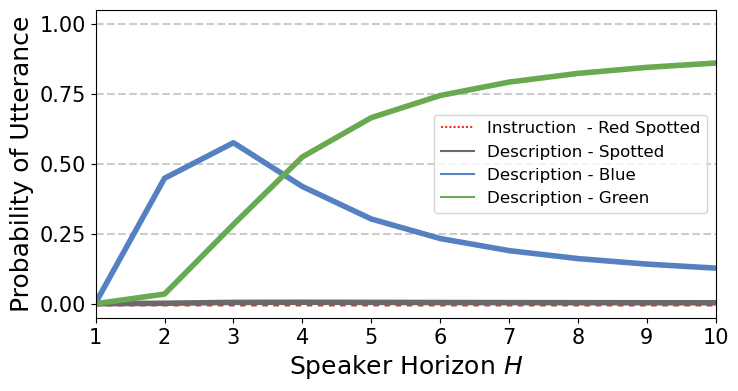

In [13]:
green = all_horizon_results[all_horizon_results.feature == "green"]
blue = all_horizon_results[all_horizon_results.feature == "blue"]
spotted = all_horizon_results[all_horizon_results.feature == "plain"]
instruction = all_horizon_results[(all_horizon_results.color == "red") & (all_horizon_results["shape"] == 'spotted')]

green_utt = "Description - Green"
blue_utt = "Description - Blue"
spotted_utt = "Description - Spotted"
instruct = "Instruction  - Red Spotted"

green["Utterance"] = green_utt
blue["Utterance"] = blue_utt
spotted["Utterance"] = spotted_utt
instruction["Utterance"] = instruct

ordering = [instruct, spotted_utt, blue_utt, green_utt]

all_utts = pd.concat([green, blue, spotted, instruction])

type_by_horizon = all_utts.groupby(["horizon", "Utterance"]).sum().reset_index()[["horizon", "Utterance", "prob"]]

plt.figure(figsize=(8, 4))
ax = sns.lineplot(data=type_by_horizon, y='prob', x='horizon', linewidth=4, hue='Utterance',
                  palette=['#ee2f24', 'dimgray', '#5580c1', '#69a94f'], hue_order=ordering,
                  style='Utterance', dashes=['', '', '', (1,1)])

plt.ylabel("Probability of Utterance", size=18)
plt.legend(loc='best', fontsize=12)

for x in [0, .25, .5, .75, 1]:
    plt.axhline(x, alpha=.2, c='k', linestyle='--', zorder=0)
    
plt.yticks([0, .25, .5, .75, 1], fontsize=15);
plt.xticks(range(1, 11), fontsize=15);
plt.xlabel("Speaker Horizon $H$", fontsize=18)
plt.xlim(1, 10)

### Multi-context: instruction-to-description

In [14]:
from configuration import UTTERANCES, ALL_STATES

from literal_listener import StatelessLiteralListener
from literal_speaker import LiteralSpeaker

def uttProbabilityS1(speaker_horizons, utterance_sets, contexts=ALL_STATES, alphaS=10):
    
    results = []
    listener = StatelessLiteralListener()
    for utt_set in utterance_sets:
             
        for h in speaker_horizons:
            
            utt_probabilities = [0] * len(UTTERANCES[utt_set])
            speaker = LiteralSpeaker(listener=listener, utterances=utt_set, alphaS=alphaS)
            
            for c in contexts:
                context_utt_probabilities = speaker.all_utterance_probabilities(c, horizon=h)
                for i, u in enumerate(context_utt_probabilities):
                    utt_probabilities[i] += u
            
            df = pd.DataFrame(UTTERANCES[utt_set])
            df["horizon"] = h
            df["utterances"] = utt_set
            df["probs"] = utt_probabilities
            df["probs"] = df["probs"] / len(contexts)
            results.append(df)
            
    return pd.concat(results)

### Increasing Context Size

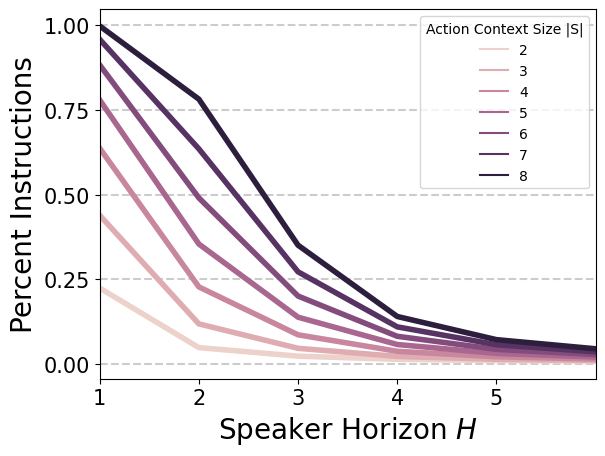

In [15]:
from configuration import ACTIONS

action_context_string = "Action Context Size |S|"

res = []
for size in range(2, 9):
    contexts = [list(l) for l in itertools.combinations(ACTIONS, size)]
    new_data = uttProbabilityS1(range(1, 11), ["all"], contexts=contexts)
    new_data[action_context_string] = size
    res.append(new_data)
    
df = pd.concat(res)

# type_by_horizon = df.groupby(["horizon", "Action Context Size", "type"]).probs.sum().reset_index()
# sns.lineplot(data=type_by_horizon, x='horizon', y='probs', hue='Action Context Size', style='type')

type_by_horizon = df[df["type"] == "instruction"].groupby(["horizon", action_context_string]).probs.sum().reset_index()
sns.lineplot(data=type_by_horizon, x='horizon', y='probs', hue=action_context_string, linewidth=4)

plt.xticks(range(0, 6), fontsize=15);
plt.ylabel("Percent Instructions", fontsize=20)
plt.xlabel("Speaker Horizon $H$", fontsize=20)
# plt.legend(fontsize=15)

plt.xlim(1, 6)

ys = [0, .25, .5, .75, 1.0]
for y in ys:
    plt.axhline(y, alpha=.2, c='k', linestyle='--', zorder=0)
plt.yticks(ys, fontsize=15);

## Utterance Utility

In [16]:
def literalUtilityFromS1(speaker_horizons, utterance_sets, contexts=ALL_STATES):
    
    results = []
    for utt_set in utterance_sets:
        
        for h in speaker_horizons:
            
            global_lit_rewards = 0
            local_lit_rewards = 0
            pct_instructions = 0
            pct_lies = 0
            
            speaker = LiteralSpeaker(listener=listener, utterances=utt_set)
            
            for c in contexts:                 
                utt_probabilities = speaker.all_utterance_probabilities(c, horizon=h)
                
                for u, p in zip(UTTERANCES[utt_set], utt_probabilities):
                    if u["type"] == "instruction":
                        pct_instructions += p
                    if u["type"] == "description" and TRUE_REWARDS[u["feature"]] != u["value"]:
                        pct_lies += p
                    global_lit_rewards += p * listener.future_rewards(u, None, TRUE_REWARDS)
                    local_lit_rewards += p * listener.present_rewards(u, c, TRUE_REWARDS)
            
            results.append({"global": global_lit_rewards/len(contexts),
                            "local": local_lit_rewards/len(contexts),
                            "pct_instructions": pct_instructions / len(contexts),
                            "pct_lies": pct_lies / len(contexts),
                            "Utterance Set": utt_set, 
                            "horizon": h})
            
    return pd.DataFrame(results)

In [17]:
size_three_contexts = [list(l) for l in itertools.combinations(ACTIONS, 3)]
size_five_contexts = [list(l) for l in itertools.combinations(ACTIONS, 5)]

contexts_to_use = size_three_contexts

In [18]:
res = literalUtilityFromS1(range(1, 11), ["instructions", "descriptions", "all"], contexts=contexts_to_use)
res["objective_utility"] = ((res["horizon"] - 1) * res["global"] + res["local"])/res["horizon"]

In [19]:
rename_dict = {"instructions": "Instructions", "descriptions": "Descriptions", "all": "All Utterances"}

res["Utterance Set"] = res["Utterance Set"].apply(lambda x: rename_dict[x])

In [20]:
grilled_cheese = res.melt(id_vars=["Utterance Set", "horizon"], 
                          value_vars=["global", "objective_utility", "local"],
                          var_name="Reward Type", value_name="rewards")

Text(0.5, 0, 'Speaker Horizon $H$')

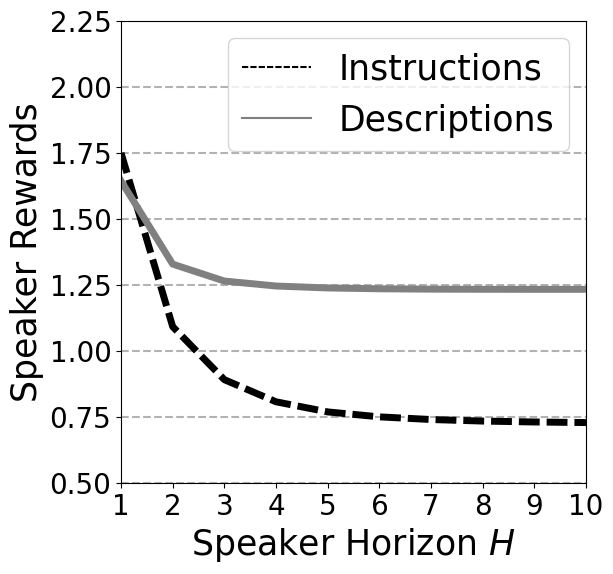

In [21]:
to_plot = grilled_cheese[grilled_cheese["Utterance Set"] != "All Utterances"]

plt.figure(figsize=(6, 6))
g = sns.lineplot(data=to_plot[to_plot['Reward Type'] == "objective_utility"], x='horizon', y='rewards', hue="Utterance Set",
                alpha=1,
                linewidth=5,
                hue_order=["Instructions", "Descriptions"], 
                palette=["k", "gray"],
                style="Utterance Set", dashes=[(3,1), ''])

# plt.ylim(.4, 2)
ys = [.5, .75, 1, 1.25, 1.5, 1.75, 2, 2.25]

plt.yticks(ys, fontsize=20)
plt.xticks(fontsize=20)
# plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlim(1, 10)
for y in ys:
    plt.axhline(y, c='k', alpha=.3, linestyle='--', zorder=0)
plt.legend(loc='best', fontsize=25)
plt.ylabel("Speaker Rewards", fontsize=25)
plt.xlabel("Speaker Horizon $H$", fontsize=25)

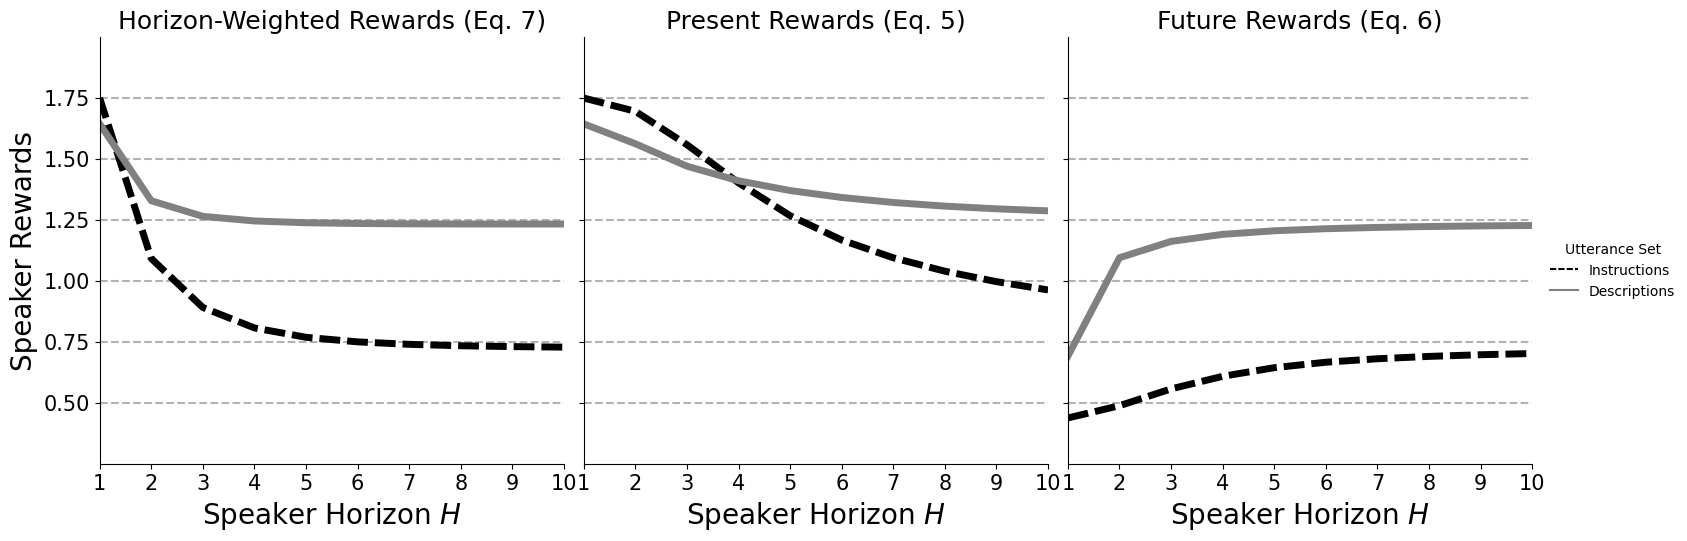

In [22]:
to_plot = grilled_cheese[grilled_cheese["Utterance Set"] != "All Utterances"]

g = sns.relplot(data=to_plot, x='horizon', y='rewards', hue="Utterance Set",
                col='Reward Type', col_order=["objective_utility", "local", "global"], kind='line',
                alpha=1,
                linewidth=5,
                hue_order=["Instructions", "Descriptions"], 
                palette=["k", "gray"],
               style="Utterance Set", dashes=[(3,1), ''])


for i, ax in enumerate(g.axes.flat):  # set every-other axis for testing purposes
    if i == 0:
        ax.set_ylabel("Speaker Rewards", fontsize=20)
        ax.set_title("Horizon-Weighted Rewards (Eq. 7)", fontsize=18)
    
    if i == 1:
        ax.set_title("Present Rewards (Eq. 5)", fontsize=18)
        
    if i == 2:
        ax.set_title("Future Rewards (Eq. 6)", fontsize=18)

    ax.set_xlabel("Speaker Horizon $H$", fontsize=20)
    ax.set_xticks(range(1,11))
    
    if contexts_to_use == size_three_contexts:
        ax.set_ylim(.25, 2)
        ys = [.5, .75, 1, 1.25, 1.5, 1.75]

    else:
        ax.set_ylim(.25, 2.5)
        ys = [.5, .75, 1, 1.25, 1.5, 1.75, 2, 2.25]

    ax.set_yticks(ys)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_xlim(1, 10)
    for y in ys:
        ax.axhline(y, c='k', alpha=.3, linestyle='--', zorder=0)

/tmp/ipykernel_135767/2820617515.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_utterances["pct_descriptions"] = 1 - all_utterances.pct_instructions


Text(0.5, 0, 'Speaker Horizon $H$')

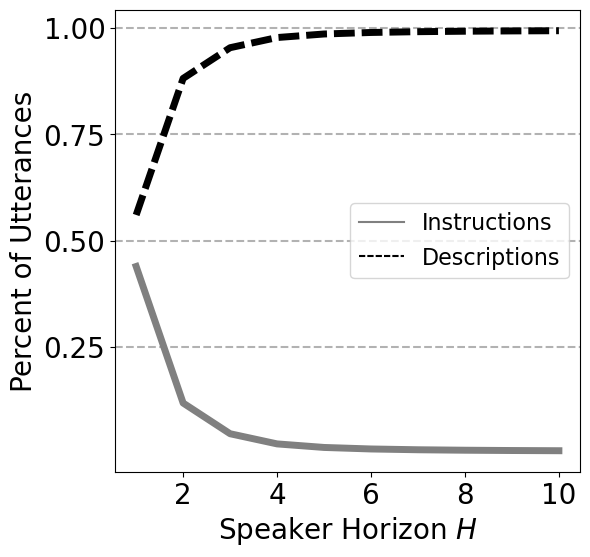

In [23]:
all_utterances = res[res["Utterance Set"] == "All Utterances"]
all_utterances["pct_descriptions"] = 1 - all_utterances.pct_instructions

by_utt_type = all_utterances.melt(id_vars=["horizon"], 
                                     value_vars=["pct_descriptions", "pct_instructions"],
                                     var_name="Utterance Type", value_name="Percent of Utterances")

rename_dict = {"pct_descriptions": "Descriptions", "pct_instructions": "Instructions"}
by_utt_type["Utterance Type"] = by_utt_type["Utterance Type"].apply(lambda x: rename_dict[x])

plt.figure(figsize=(6, 6))
g = sns.lineplot(data=by_utt_type, x='horizon', y='Percent of Utterances', hue="Utterance Type",
                alpha=1,
                linewidth=5,
                hue_order=["Instructions", "Descriptions"], 
                palette=["gray", "k"],
                style="Utterance Type", dashes=[(3,1), ''])

ys = [.25, .5, .75, 1]

plt.yticks(ys, fontsize=20)
plt.xticks(fontsize=20)

for y in ys:
    plt.axhline(y, c='k', alpha=.3, linestyle='--', zorder=0)
plt.legend(loc='best', fontsize=16)
plt.ylabel("Percent of Utterances", fontsize=20)
plt.xlabel("Speaker Horizon $H$", fontsize=20)

# Pragmatic Listener

## Beliefs from Utterances

In [24]:
from pragmatic_listener import PragmaticListener
from visualizations import plot_point_estimate, plot_full_posterior, plot_horizon_estimate

base_listener = StatelessLiteralListener(alphaL=3)
base_speaker = LiteralSpeaker(listener=base_listener, alphaS=10, utterances="all")

pragmatic_listener = PragmaticListener(base_speaker)

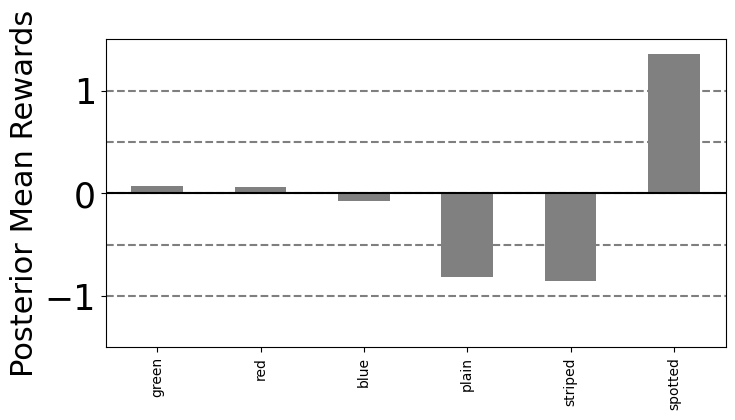

In [25]:
description_to_use = {"type": "description", "feature": "spotted", "value": 1}

description_posterior = pragmatic_listener.inference(description_to_use, TEST_CONTEXT, horizon=[1, 2, 3, 4, 5, 10])
point_estimate = pragmatic_listener.point_estimate_from_posterior(description_posterior)
plot_point_estimate(point_estimate)

### Inference over horizon

In [26]:
from configuration import FEATURES

theory_to_mushrooms = {"red": "Red", "green": "Green", "blue": "Blue", 
                       "plain": "Spotted", "striped": "Solid", "spotted": "Striped"}

MUSHROOM_FEATURES = [theory_to_mushrooms.get(k) for k in FEATURES]

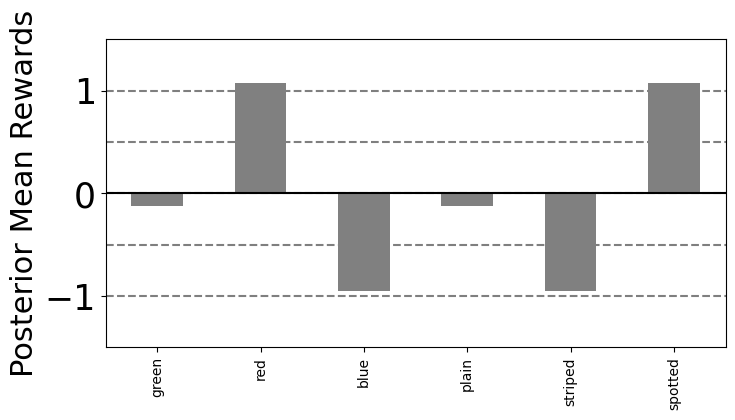

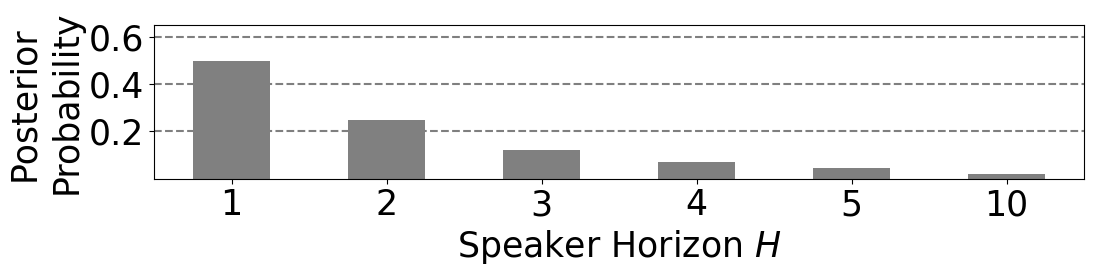

In [27]:
instruction = {"type": "instruction", "color": "red", "shape":"spotted"}
reward_belief_df = pragmatic_listener.inference(instruction, TEST_CONTEXT, horizon=[1, 2, 3, 4, 5, 10])

point_estimate = pragmatic_listener.point_estimate_from_posterior(reward_belief_df)
plot_point_estimate(point_estimate)
plot_horizon_estimate(reward_belief_df)

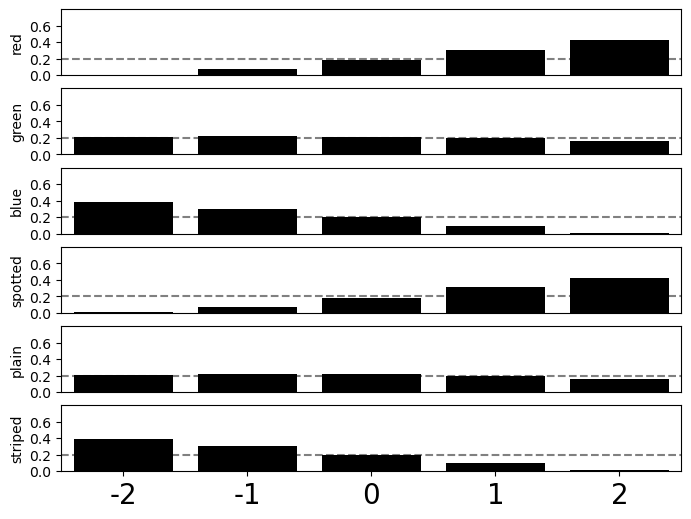

In [28]:
plot_full_posterior(reward_belief_df, ylabel=True)

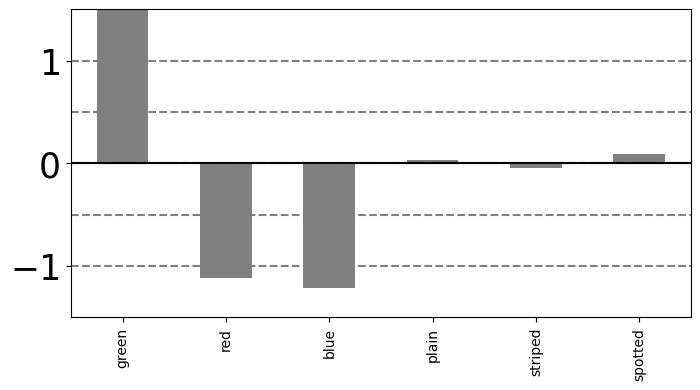

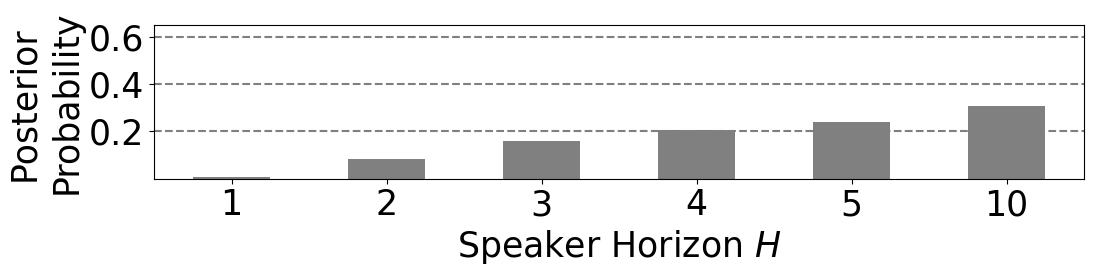

In [29]:
description = {"type": "description", "feature": "green", "value":2}
reward_belief_df = pragmatic_listener.inference(description, TEST_CONTEXT, horizon=[1, 2, 3, 4, 5, 10])

point_estimate = pragmatic_listener.point_estimate_from_posterior(reward_belief_df)
plot_point_estimate(point_estimate, include_text=False)
plot_horizon_estimate(reward_belief_df, include_text=True, include_ticks=True)

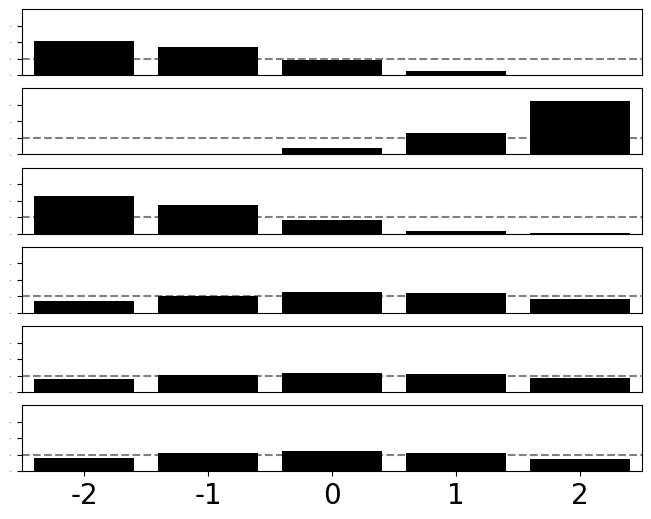

In [30]:
plot_full_posterior(reward_belief_df, ylabel=False)

## Cache Pragmatic Inference

In [31]:
import time
from os.path import exists

from configuration import ALL_STATES, UTTERANCES


##### Experimental settings #####
utterances_to_cache = "exp"
horizons = [1, 2, 4]
alphaSes = [3] 

##### Theoretical settings ######
# utterances_to_cache = "all"
# horizons = [1, 2, 3, 4, 5, 10]
# alphaSes = [10]

for alphaS in alphaSes:
    to_cache_listener = StatelessLiteralListener()
    to_cache_speaker = LiteralSpeaker(listener=to_cache_listener, utterances=utterances_to_cache, alphaS=alphaS)
    to_cache_pragmatic_listener = PragmaticListener(speaker=to_cache_speaker)

    for h in horizons:
    
        n_completed = 0
        n_in_horizon = len(ALL_STATES) * len(UTTERANCES[utterances_to_cache])
        print(f'Horizon {h}: {n_in_horizon} utterance-context pairs.') 
        for c in ALL_STATES:
            for u in UTTERANCES[utterances_to_cache]:

                start_time_ms = round(time.time() * 1000)
                to_cache_pragmatic_listener.inference(u, c, h)
                end_time_ms = round(time.time() * 1000)

                n_seconds = (end_time_ms - start_time_ms)/1000
                if n_completed % 10 == 0 and n_seconds > 1:
                    print("\tRan #{} in {:.2f} seconds.".format(n_completed, n_seconds))
                n_completed += 1

Horizon 1: 3276 utterance-context pairs.
	Ran #0 in 1.65 seconds.
	Ran #10 in 1.59 seconds.
	Ran #20 in 1.58 seconds.
	Ran #30 in 1.59 seconds.
	Ran #40 in 1.61 seconds.
	Ran #50 in 1.57 seconds.
	Ran #60 in 1.59 seconds.
	Ran #70 in 1.59 seconds.
	Ran #80 in 1.57 seconds.
	Ran #90 in 1.58 seconds.
	Ran #100 in 1.56 seconds.
	Ran #110 in 1.58 seconds.
	Ran #150 in 1.61 seconds.
	Ran #190 in 1.58 seconds.
	Ran #200 in 1.59 seconds.
	Ran #210 in 1.58 seconds.
	Ran #220 in 1.59 seconds.
	Ran #230 in 1.57 seconds.
	Ran #240 in 1.61 seconds.
	Ran #250 in 1.61 seconds.
	Ran #260 in 1.60 seconds.
	Ran #270 in 1.59 seconds.
	Ran #280 in 1.57 seconds.
	Ran #290 in 1.57 seconds.
	Ran #300 in 1.56 seconds.
	Ran #310 in 1.57 seconds.
	Ran #350 in 1.60 seconds.
	Ran #390 in 1.58 seconds.
	Ran #400 in 1.55 seconds.
	Ran #410 in 1.55 seconds.
	Ran #420 in 1.57 seconds.
	Ran #430 in 1.58 seconds.
	Ran #440 in 1.61 seconds.
	Ran #450 in 1.59 seconds.
	Ran #460 in 1.61 seconds.
	Ran #470 in 1.57 seconds

# Simulations for Paper

In [32]:
def futureRewardsLiteralPragmatic(pragmatic_listener, speaker_horizon, listener_horizons, utterance_set_name, contexts):
    """Given speaker / listener horizon(s) and utterances, return L0/L1 rewards."""
    
    pragmatic_rewards = 0
    literal_rewards = 0
    
    literal_listener = StatelessLiteralListener()
    
    for i, c in enumerate(contexts):
        
        utt_set = UTTERANCES[utterance_set_name]
        utt_probabilities = pragmatic_listener.speaker.all_utterance_probabilities(c, horizon=speaker_horizon)

        for u, p in zip(utt_set, utt_probabilities):
            
            pragmatic_rewards += p * pragmatic_listener.future_rewards(u, c, TRUE_REWARDS, listener_horizons)
            literal_rewards += p * literal_listener.future_rewards(u, context=None, rewards=TRUE_REWARDS)
        
    return literal_rewards / len(contexts), pragmatic_rewards / len(contexts)

## Simulation of literal / pragmatic listeners

#### Config: Theoretical

- `all` utterances
- `alphaS` = 10
- `horizon` = [1-10]

In [33]:
# utterances_for_plot = "all"
# horizons_for_plot = [1, 2, 3, 4, 5, 10]
# alphaS = 10

#### Config: Experimental
- `exp` utterances
- `alphaS` = 3
- `horizon` = [1,2,4]

In [34]:
utterances_for_plot = "exp"
horizons_for_plot = [1, 2, 4]
alphaS = 3

#### Run various simulations

In [35]:
listener = StatelessLiteralListener()
speaker = LiteralSpeaker(listener, utterances=utterances_for_plot, alphaS=alphaS)
pragmatic_listener = PragmaticListener(speaker)

#### Known Horizon

In [36]:
results = []
for h in horizons_for_plot:
    print("Running horizon {}.".format(h))
    literal, pragmatic = futureRewardsLiteralPragmatic(pragmatic_listener, h, h, utterances_for_plot, contexts=ALL_STATES)
    results.append({"horizon":h, 
                    "alpha": a,
                    "literal": literal, 
                    "pragmatic": pragmatic, 
                    "pragmatic_diff": pragmatic-literal})
    
aligned_df = pd.DataFrame(results)

Running horizon 1.
Running horizon 2.
Running horizon 4.


#### Pedagogic Assumption ($H=4$)

In [37]:
results = []
for h in horizons_for_plot:
    literal, pragmatic = futureRewardsLiteralPragmatic(pragmatic_listener, h, max(horizons_for_plot), utterances_for_plot, contexts=ALL_STATES)
    results.append({"horizon":h, 
                    "literal": literal, 
                    "pragmatic": pragmatic, 
                    "pragmatic_diff": pragmatic-literal})
    
pedagogic_assumption_df = pd.DataFrame(results)

#### Locally-optimal assumption ($H=1$)

In [38]:
results = []
for h in horizons_for_plot:
    literal, pragmatic = futureRewardsLiteralPragmatic(pragmatic_listener, h, 1, utterances_for_plot, contexts=ALL_STATES)
    results.append({"horizon":h, 
                    "literal": literal, 
                    "pragmatic": pragmatic, 
                    "pragmatic_diff": pragmatic-literal})
    
conservative_listener = pd.DataFrame(results)

### Uncertain Pragmatic Listener

In [39]:
results = []
for h in horizons_for_plot:
    literal, pragmatic = futureRewardsLiteralPragmatic(pragmatic_listener, h, horizons_for_plot, utterances_for_plot, contexts=ALL_STATES)
    results.append({"horizon":h, 
                    "literal": literal, 
                    "pragmatic": pragmatic, 
                    "pragmatic_diff": pragmatic-literal})
    
joint_inference_df = pd.DataFrame(results)

In [40]:
aligned_df["calibration"] = "Known Horizon"
pedagogic_assumption_df["calibration"] = "Pedagogic Assumption (H=4)"
conservative_listener["calibration"] = "Conservative Assumption (H=1)"
joint_inference_df["calibration"] = "Joint Inference"

full_df = pd.concat([aligned_df, pedagogic_assumption_df, conservative_listener, joint_inference_df])

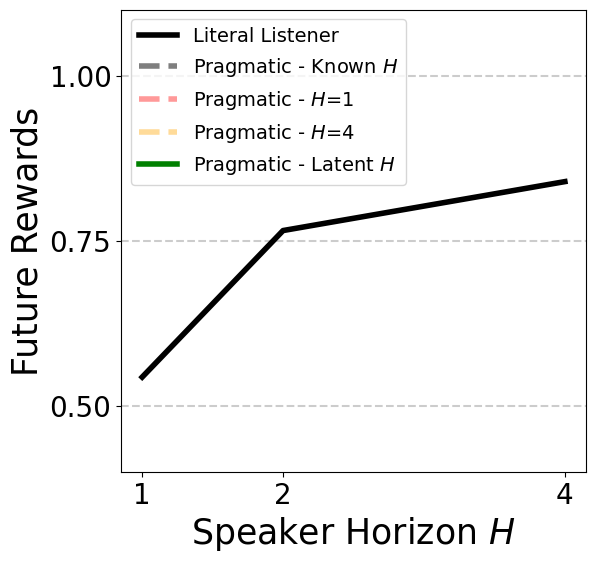

In [41]:
full_df["horizon"] = full_df["horizon"].apply(lambda x: 7 if x == 10 else x)

plt.figure(figsize=(6,6))

known_horizon = full_df[full_df["calibration"] == "Known Horizon"]
plt.plot(known_horizon.horizon, known_horizon.literal, c='k', linewidth=4, alpha=1, label="Literal Listener")

plt.plot(known_horizon.horizon, known_horizon.pragmatic, c='k', linestyle='--', linewidth=4, alpha=.5, label="Pragmatic - Known $H$")

conservative = full_df[full_df["calibration"] == "Conservative Assumption (H=1)"]
plt.plot(conservative.horizon, conservative.pragmatic, c='r', linestyle='--', linewidth=4, alpha=.4, label="Pragmatic - $H$=1")

myopic_speaker = full_df[full_df["calibration"] == "Pedagogic Assumption (H=4)"]
plt.plot(myopic_speaker.horizon, myopic_speaker.pragmatic, c='orange', linestyle='--', linewidth=4, alpha=.4, label=f'Pragmatic - $H$={max(horizons_for_plot)}')


joint = full_df[full_df["calibration"] == "Joint Inference"]
plt.plot(joint.horizon, joint.pragmatic, c='g', linewidth=4, alpha=1, label="Pragmatic - Latent $H$")


plt.ylabel("Future Rewards", size=25)
plt.xlabel("Speaker Horizon $H$", fontsize=25)

if horizons_for_plot == [1, 2, 3, 4, 5, 10]:

    plt.xticks([1, 2, 3, 4, 5, 7], labels=[1, 2, 3, 4, 5, 10], size=20);
    plt.ylim(.45, 1.30)
    yticks = [.5, .75, 1, 1.25]
    plt.yticks(yticks, size=20)

else: 
    
    plt.xticks([1, 2, 4], size=20)
    plt.ylim(.4, 1.1)
    yticks = [.5, .75, 1]
    plt.yticks(yticks, size=20)

for y in yticks:
    plt.axhline(y, linestyle='--', c='k', alpha=.2, zorder=0)

# plt.show()

plt.legend(loc='best', fontsize=14)

In [42]:
full_df.groupby(['calibration', 'horizon']).pragmatic.mean()

calibration                    horizon
Conservative Assumption (H=1)  1          0.138515
                               2         -0.060873
                               4         -0.126824
Joint Inference                1          0.149025
                               2         -0.057752
                               4         -0.136286
Known Horizon                  1          0.138515
                               2         -0.053547
                               4         -0.128779
Pedagogic Assumption (H=4)     1          0.139245
                               2         -0.052308
                               4         -0.128779
Name: pragmatic, dtype: float64

# Behavioral Data

In [43]:
human_utterances = json.load(open("data/IMU_risk.json"))

## Analysis of chosen utterances

In [44]:
def literalUtilityFromUtterances(human_utterances, contexts=ALL_STATES):
    
    results = []
    horizons = list(set([u["horizon"] for u in human_utterances]))
        
    for h in horizons:
        
        h_utterances = [u for u in human_utterances if u["horizon"] == h]    
        global_lit_rewards = 0
        local_lit_rewards = 0
        instructions = 0
        lies = 0            

        utterances = [d["utt"] for d in h_utterances]
        contexts = [d["action_context"] for d in h_utterances]
        for u, c in zip(utterances, contexts):
            
            if u["type"] == "instruction":
                instructions += 1
            if u["type"] == "description" and TRUE_REWARDS[u["feature"]] != u["value"]:
                lies += 1
                
            global_lit_rewards += listener.future_rewards(u, None, TRUE_REWARDS)
            local_lit_rewards += listener.present_rewards(u, c, TRUE_REWARDS)

        results.append({"global": global_lit_rewards/len(h_utterances),
                        "local": local_lit_rewards/len(h_utterances),
                        "pct_instructions": instructions / len(h_utterances),
                        "pct_lies": lies / len(h_utterances),
                        "n_utterances": len(h_utterances),
                        "horizon": h})

    return pd.DataFrame(results)

In [45]:
res = literalUtilityFromUtterances(human_utterances)
res["objective_utility"] = (res["local"] + (res["horizon"]-1) * res["global"])/res["horizon"]

In [46]:
grilled_cheese = res.melt(id_vars=["horizon"], 
                          value_vars=["global", "objective_utility", "local"],
                          var_name="Reward Type", value_name="rewards")

## Analysis of pragmatics

In [47]:
def futureRewardsFromExperiment(pragmatic_listener, human_utterances, horizons=None):
    """Given speaker / listener horizon(s) and utterances, return L0/L1 rewards."""
    
    results = []
    literal_listener = StatelessLiteralListener()
    
    if horizons is None:
        horizons = list(set([u["horizon"] for u in human_utterances]))
    
    for h in horizons:
        
        h_utterances = [u for u in human_utterances if u["horizon"] == h]
        
        print(f"Horizon {h}: {len(h_utterances)} utterances.")
        
        for i, u in enumerate(h_utterances):
            
            u = copy.deepcopy(u)
                                    
            literal = literal_listener.future_rewards(u["utt"], context=None, rewards=TRUE_REWARDS)
            
            pragmatic_aligned = pragmatic_listener.future_rewards(u["utt"], u["action_context"], TRUE_REWARDS, h)            
            pragmatic_conservative = pragmatic_listener.future_rewards(u["utt"], u["action_context"], TRUE_REWARDS, 1)
            pragmatic_long_horizon = pragmatic_listener.future_rewards(u["utt"], u["action_context"], TRUE_REWARDS, 4)
            pragmatic_uncertain = pragmatic_listener.future_rewards(u["utt"], u["action_context"], TRUE_REWARDS, horizons)
        
            uncertain_posterior = pragmatic_listener.inference(u["utt"], u["action_context"], horizons)
            horizon_estimate = uncertain_posterior.multiply(uncertain_posterior["probability"], axis='index').apply(np.sum)["horizon"]
            point_estimate = pragmatic_listener.point_estimate_from_posterior(uncertain_posterior)
            
            u["literal"] = literal
            u["pragmatic_aligned"] = pragmatic_aligned
            u["pragmatic_uncertain"] = pragmatic_uncertain

            u["pragmatic_conservative"] = pragmatic_conservative
            u["pragmatic_pedagogic"] = pragmatic_long_horizon
            
            u["horizon_estimate"] = horizon_estimate
            u["point_estimate"] = point_estimate
            
            results.append(u)
        
    return results

In [48]:
alphaS = 3

all_results = []

literal = StatelessLiteralListener()
speaker = LiteralSpeaker(literal, utterances="exp", alphaS=alphaS)
pragmatic_listener = PragmaticListener(speaker)

results = futureRewardsFromExperiment(pragmatic_listener, human_utterances)

res = pd.DataFrame(results)
res["alphaS"] = alphaS
all_results.append(res)
    
res = pd.concat(all_results)

Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utterances.
Horizon 4: 27 utterances.


In [49]:
rename_dict = {"pragmatic_aligned": "Pragmatic - Known $H$",
               "pragmatic_uncertain": "Pragmatic - Latent $H$",
               "pragmatic_conservative": "Pragmatic - $H$=1",
               "pragmatic_pedagogic": "Pragmatic - $H$=4",
               "literal": "Literal Listener"}

to_plot_human_data = res.melt(id_vars="horizon", var_name="listener", value_name="rewards",
                   value_vars=["literal", "pragmatic_aligned", "pragmatic_uncertain", "pragmatic_conservative", "pragmatic_pedagogic"]) 

to_plot_human_data["listener"] = to_plot_human_data.listener.apply(lambda x: rename_dict[x])

(0.4, 1.1)

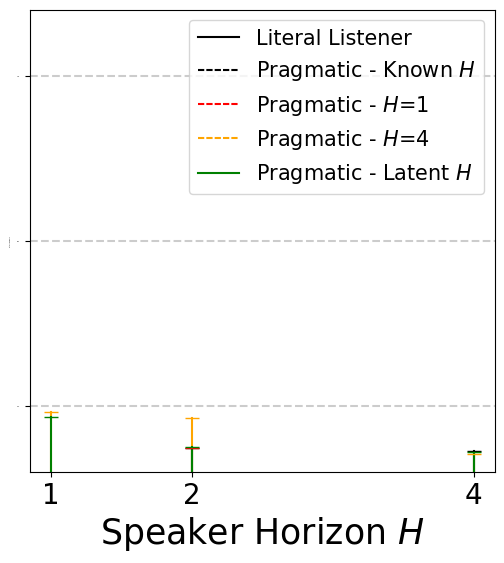

In [50]:
plt.figure(figsize=(6,6))

sns.lineplot(data=to_plot_human_data, x='horizon', y="rewards", hue="listener", 
             ci=95, err_style='bars', err_kws={"capsize": 5},
             hue_order=["Literal Listener", "Pragmatic - Known $H$", "Pragmatic - $H$=1", "Pragmatic - $H$=4", "Pragmatic - Latent $H$"],
             palette=["k", "k", "r", 'orange', "g"],  linewidth=4, alpha=1, style='listener', dashes=['', (3,1), '', (3,1), (3,1)])

plt.xticks([1, 2, 4], size=20)
plt.xlabel("Speaker Horizon $H$", fontsize=25)

yticks = [.5, .75, 1, 1.25]
plt.yticks(yticks, size=0)
for y in yticks:
    plt.axhline(y, linestyle='--', c='k', alpha=.2, zorder=0)
    
plt.ylabel("Future Rewards", fontsize=0)

ax_children = plt.gca().get_children()
print()

# pragmatic - known h
plt.setp([ax_children[9]],alpha=.4)

# pragmatic- h = 1
plt.setp([ax_children[2]],alpha=.4)
plt.setp([ax_children[13]],alpha=.4)

# pragmatic- h = 4
plt.setp([ax_children[17]],alpha=.4)

plt.legend(fontsize=15)
plt.ylim(.4, 1.1)

In [51]:
from configuration import utt_to_string, context_to_string

res["item_key"] = res.apply(lambda x: f'{utt_to_string(x["utt"])}|{context_to_string(x["action_context"])}|{x["workerid"]}', axis=1)

### Calculate means / export to R

In [52]:
res_to_export = res.drop(['action_context', 'workerid', 'horizon', 'utt', 'horizon_estimate', 'point_estimate', 'alphaS', "item_key"], axis=1)
res_to_export.to_csv("utterance_posterior_rewards.csv", index=False)

In [53]:
res[['literal', 'pragmatic_uncertain', 'pragmatic_aligned', 'pragmatic_conservative', 'pragmatic_pedagogic']].describe().round(2)

,literal,pragmatic_uncertain,pragmatic_aligned,pragmatic_conservative,pragmatic_pedagogic
count,108.00,108.00,108.00,108.00,108.00
mean,0.01,0.02,0.01,-0.00,0.03
std,0.58,0.81,0.78,0.73,0.81
min,-1.28,-1.48,-1.45,-1.47,-1.43
25%,-0.48,-0.47,-0.38,-0.45,-0.48
50%,0.00,0.00,0.00,-0.00,0.00
75%,0.25,0.45,0.45,0.45,0.45
max,1.28,1.21,1.32,1.13,1.32


## Appendix E: Pragmatic Inference Details

In [54]:
res["instruct_color"] = res.utt.apply(lambda x: x.get("color"))
res["instruct_shape"] = res.utt.apply(lambda x: x.get("shape"))
res["descript_feature"] = res.utt.apply(lambda x: x.get("feature", "instruction"))
res["descript_value"] = res.utt.apply(lambda x: x.get("value"))
res["instruction"] = res.utt.apply(lambda x: x.get("type") == "instruction")

In [55]:
res["pragmatic_aligned_diff"] = res.pragmatic_aligned - res.literal
res["pragmatic_uncertain_diff"] = res.pragmatic_uncertain - res.literal

In [56]:
res["Utterance Type"] = res.instruction.apply(lambda x: "Instruction" if x else "Description")

Text(0, 0.5, 'Utterance Count')

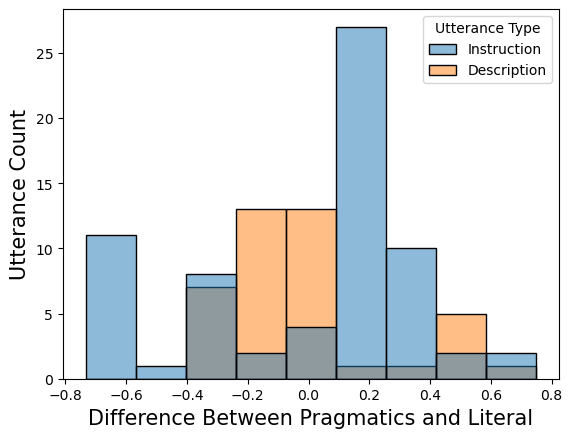

In [57]:
sns.histplot(data=res, hue="Utterance Type", x='pragmatic_uncertain_diff')
plt.xlabel("Difference Between Pragmatics and Literal", fontsize=15)
plt.ylabel("Utterance Count", fontsize=15)

In [58]:
res.groupby("Utterance Type")[["pragmatic_uncertain_diff"]].describe().round(3)

pragmatic_uncertain_diff                                     \
                                  count   mean    std    min    25%    50%   
Utterance Type                                                               
Description                        41.0  0.006  0.265 -0.357 -0.161 -0.044   
Instruction                        67.0  0.004  0.416 -0.734 -0.354  0.203   

                              
                  75%    max  
Utterance Type                
Description     0.040  0.743  
Instruction     0.203  0.750

In [59]:
pragmatic_difference_descriptions = res[~res.instruction].pragmatic_uncertain_diff
stats.ttest_1samp(pragmatic_difference_descriptions, 0)

Ttest_1sampResult(statistic=0.14264347601927094, pvalue=0.8872878723896571)

In [60]:
pragmatic_difference_instructions = res[res.instruction].pragmatic_uncertain_diff
stats.ttest_1samp(pragmatic_difference_instructions, 0)

Ttest_1sampResult(statistic=0.08037578235748231, pvalue=0.936181615013187)

In [61]:
res.groupby("descript_feature").pragmatic_uncertain_diff.describe().round(3)

,count,mean,std,min,25%,50%,75%,max
descript_feature,,,,,,,,
blue,6.0,-0.190,0.062,-0.265,-0.246,-0.169,-0.141,-0.130
green,4.0,-0.217,0.090,-0.262,-0.262,-0.262,-0.217,-0.082
instruction,67.0,0.004,0.416,-0.734,-0.354,0.203,0.203,0.750
plain,9.0,-0.105,0.154,-0.357,-0.086,-0.086,0.005,0.052
red,5.0,0.192,0.327,-0.024,0.000,0.000,0.243,0.743
spotted,10.0,0.283,0.250,-0.044,0.040,0.426,0.496,0.496
striped,7.0,-0.085,0.083,-0.168,-0.165,-0.097,-0.000,0.000


In [62]:
res.groupby(["instruct_color", "instruct_shape"]).pragmatic_aligned_diff.describe()

count      mean       std       min       25%  \
instruct_color instruct_shape                                                  
blue           spotted          11.0 -0.704664  0.000000 -0.704664 -0.704664   
               striped           1.0 -0.408616       NaN -0.408616 -0.408616   
green          spotted          23.0  0.214289  0.143170 -0.237340  0.200027   
               plain            13.0  0.359289  0.338437 -0.750000  0.439418   
red            spotted           2.0  0.000033  0.353506 -0.249934 -0.124950   
               striped          10.0 -0.210270  0.170218 -0.314633 -0.314633   
               plain             5.0  0.204308  0.000000  0.204308  0.204308   

                                    50%       75%       max  
instruct_color instruct_shape                                
blue           spotted        -0.704664 -0.704664 -0.704664  
               striped        -0.408616 -0.408616 -0.408616  
green          spotted         0.200027  0.204308  0.563463  
               plain           0.439418  0.439418  0.566077  
red            spotted         0.000033  0.125017  0.250000  
               striped        -0.314633 -0.078658  0.099729  
               plain           0.204308  0.204308  0.204308

## Appendix C: Choosing $\beta_{S_1}$

In [63]:
alphaTestResults = []
horizons = [1, 2, 4]
alphas = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for alpha in alphas:
    
    print(f'AlphaS: {alpha}.')

    literal = StatelessLiteralListener()
    speaker = LiteralSpeaker(literal, utterances="exp", alphaS=alpha)
    pragmatic_listener = PragmaticListener(speaker)

    results = futureRewardsFromExperiment(pragmatic_listener, human_utterances)
    res = pd.DataFrame(results)
    res["alphaS"] = alpha
    alphaTestResults.append(res)
    
alphaTest = pd.concat(alphaTestResults)

AlphaS: 1.
Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utterances.
Horizon 4: 27 utterances.
AlphaS: 2.
Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utterances.
Horizon 4: 27 utterances.
AlphaS: 3.
Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utterances.
Horizon 4: 27 utterances.
AlphaS: 4.
Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utterances.
Horizon 4: 27 utterances.
AlphaS: 5.
Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utterances.
Horizon 4: 27 utterances.
AlphaS: 6.
Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utterances.
Horizon 4: 27 utterances.
AlphaS: 7.
Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utterances.
Horizon 4: 27 utterances.
AlphaS: 8.
Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utterances.
Horizon 4: 27 utterances.
AlphaS: 9.
Horizon 1: 27 utterances.
Horizon 2: 27 utterances.
Horizon 3: 27 utt

Text(0, 0.5, 'Future Rewards')

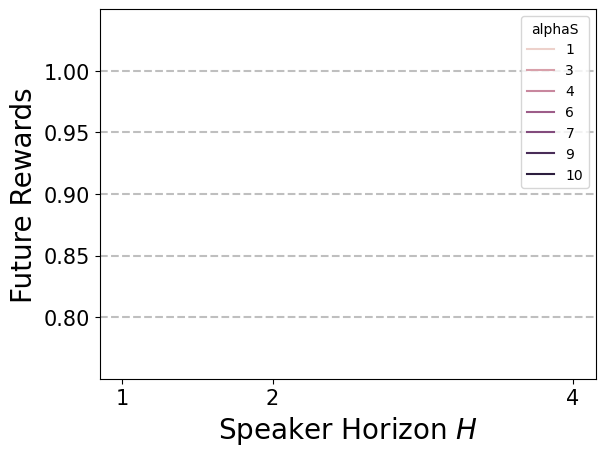

In [64]:
alphaTestToPlot = alphaTest

sns.lineplot(data=alphaTestToPlot, x='horizon', y='pragmatic_aligned', hue='alphaS', err_style='bars', err_kws={"capsize": 5}, 
             linewidth=4, alpha=.8)

ys = [.8, .85, .9, .95, 1]
for y in ys:
    plt.axhline(y, alpha=.25, linestyle='--', zorder=0, c='k')
plt.yticks(ys, fontsize=15)
plt.xticks([1, 2, 4], fontsize=15)
    
plt.ylim(.75, 1.05)

plt.xlabel("Speaker Horizon $H$", fontsize=20)
plt.ylabel("Future Rewards", fontsize=20)

Text(0, 0.5, 'Future Rewards')

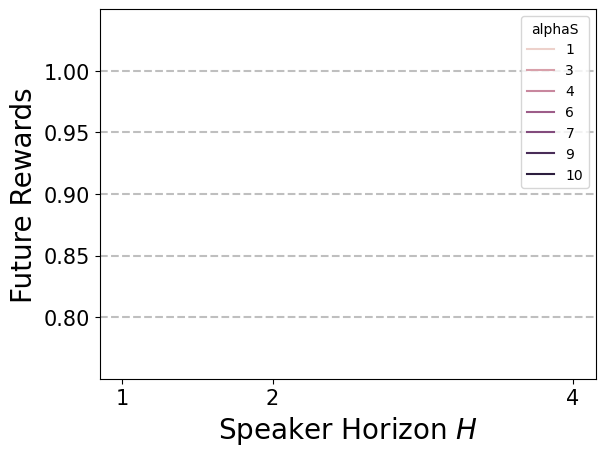

In [65]:
sns.lineplot(data=alphaTestToPlot, x='horizon', y='pragmatic_uncertain', hue='alphaS', err_style='bars', err_kws={"capsize": 5}, 
             linewidth=4, alpha=.8)

ys = [.8, .85, .9, .95, 1]
for y in ys:
    plt.axhline(y, alpha=.25, linestyle='--', zorder=0, c='k')
plt.yticks(ys, fontsize=15)
plt.xticks([1, 2, 4], fontsize=15)
    
plt.ylim(.75, 1.05)

plt.xlabel("Speaker Horizon $H$", fontsize=20)
plt.ylabel("Future Rewards", fontsize=20)

In [66]:
melted = alphaTestToPlot.melt(id_vars=["alphaS"], 
                          value_vars=["pragmatic_aligned", "pragmatic_uncertain"],
                          var_name="speaker", value_name="rewards")

rename_dict = {"pragmatic_aligned": "Known $H$", "pragmatic_uncertain": "Latent $H$"}
melted["speaker"] = melted.speaker.apply(lambda x: rename_dict[x])

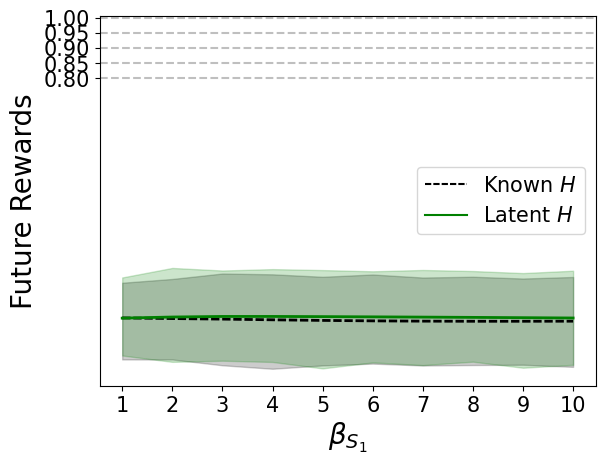

In [67]:
sns.lineplot(data=melted, x='alphaS', y='rewards', hue='speaker',
            hue_order=["Known $H$", "Latent $H$"],
            palette=['k', 'g'],
             linewidth=2, style='speaker', dashes=[(3,1), ''])

plt.legend(loc='best', fontsize=15)

ys = [.8, .85, .9, .95, 1]
for y in ys:
    plt.axhline(y, alpha=.25, linestyle='--', zorder=0, c='k')
plt.yticks(ys, fontsize=15)
plt.xticks(range(1, 11), fontsize=15);

plt.ylabel("Future Rewards", fontsize=20)
plt.xlabel(r"$\beta_{S_1}$", fontsize=20);

In [68]:
print(alphaTestToPlot.groupby(["alphaS"])[["pragmatic_aligned", "pragmatic_uncertain"]].mean().round(4).style.to_latex())

\begin{tabular}{lrr}
 & pragmatic_aligned & pragmatic_uncertain \\
alphaS &  &  \\
1 & 0.012300 & 0.011600 \\
2 & 0.010200 & 0.015300 \\
3 & 0.008300 & 0.017100 \\
4 & 0.006100 & 0.017100 \\
5 & 0.004100 & 0.016500 \\
6 & 0.002600 & 0.015800 \\
7 & 0.001700 & 0.015000 \\
8 & 0.001300 & 0.014100 \\
9 & 0.001300 & 0.013100 \\
10 & 0.001500 & 0.012000 \\
\end{tabular}



In [69]:
alpha_three_known_h = alphaTestToPlot[alphaTestToPlot.alphaS == 3]["pragmatic_aligned"]
alpha_two_known_h = alphaTestToPlot[alphaTestToPlot.alphaS == 2]["pragmatic_aligned"]

stats.ttest_rel(alpha_three_known_h, alpha_two_known_h)

Ttest_relResult(statistic=-0.46110336013644526, pvalue=0.6456603669353856)